In [145]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
plt.rcParams.update({'font.size': 16, 'figure.figsize': (8, 8)})

In [146]:
#  Constants (in astronomical units)
G  = 4 * np.pi**2          
M  = 1.0    #Mass of the sun               
GM = G * M                 

In [147]:
def acceleration(x, y):
    r = np.sqrt(x**2 + y**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    
    return ax, ay

In [167]:
# Euler Method

def euler_method(x0,y0,vx0,vy0,h,N):
    x = np.zeros(N+1)  
    y = np.zeros(N+1)
    vx = np.zeros(N+1)  
    vy = np.zeros(N+1)
    x[0] = x0
    y[0] = y0
    vx[0] = vx0
    vy[0] = vy0

    for i in range(N):

        ax , ay = acceleration(x[i],y[i])
        # Velocity update
        vx[i+1] = vx[i] + ax * h
        vy[i+1] = vy[i] + ay * h

        # Position update
        x[i+1] = x[i] + vx[i] * h
        y[i+1] = y[i] + vy[i] * h

    return x,y,vx,vy


In [168]:
def Leapfrog_method(x0,y0,vx0,vy0,h,N):
    x = np.zeros(N+1)  
    y = np.zeros(N+1)
    vx = np.zeros(N+1)  
    vy = np.zeros(N+1)
    x[0] = x0
    y[0] = y0
    vx[0] = vx0
    vy[0] = vy0

    for i in range(N):
        ax, ay = acceleration(x[i],y[i])
        vxhalf = vx[i] + 0.5 * ax * h
        vyhalf = vy[i] + 0.5 * ay * h

        x[i+1] = x[i] + vxhalf * h
        y[i+1] = y[i] + vyhalf * h

        ax, ay = acceleration(x[i+1],y[i+1])

        vx[i+1] = vxhalf + 0.5 * ax * h
        vy[i+1] = vyhalf + 0.5 * ay * h

    return x,y,vx,vy


In [169]:
#  Initial conditions – circular orbit at r0 = 1 AU
r0 = 1.0                            # initial distance [AU]
v_circ = np.sqrt(GM / r0)           # circular speed [AU/yr]  => 2*pi AU/yr

x0 = r0
y0 = 0
vx0 = 0
vy0 = v_circ

#  Simulation parameters

T = 3.0             # 3 orbital periods
dt      = 1e-3            # time step [yr](This is the step size h)
N = int(T / dt)

x1,y1,vx1,vy1 = euler_method(x0,y0,vx0,vy0,dt, N)
x2,y2,vx2,vy2 = Leapfrog_method(x0,y0,vx0,vy0,dt, N)

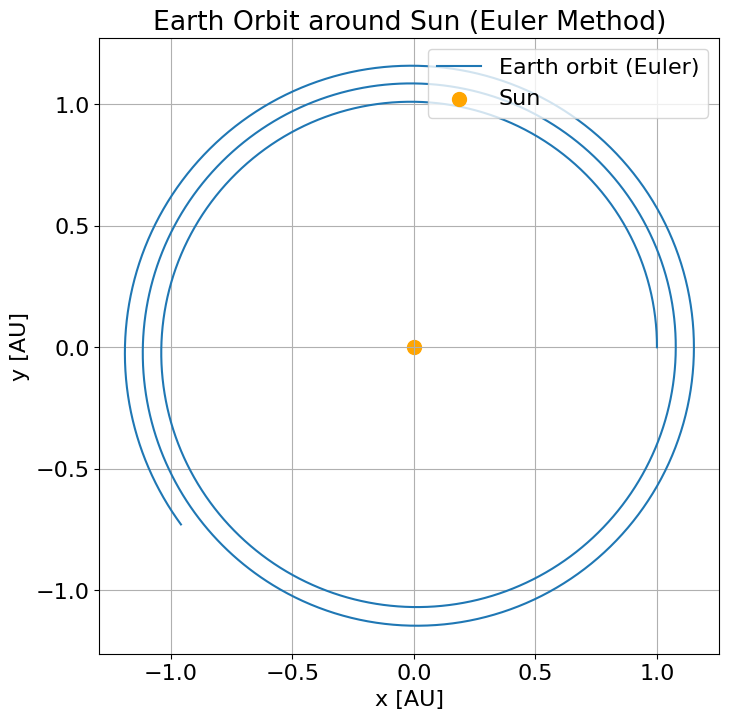

In [170]:
# Plotting the orbit for Euler method
plt.plot(x1, y1, label='Earth orbit (Euler)')
plt.scatter(0, 0, color='orange', s=100, label='Sun')  # Sun at origin
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Earth Orbit around Sun (Euler Method)')
plt.axis('equal')  # equal scaling for x and y
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

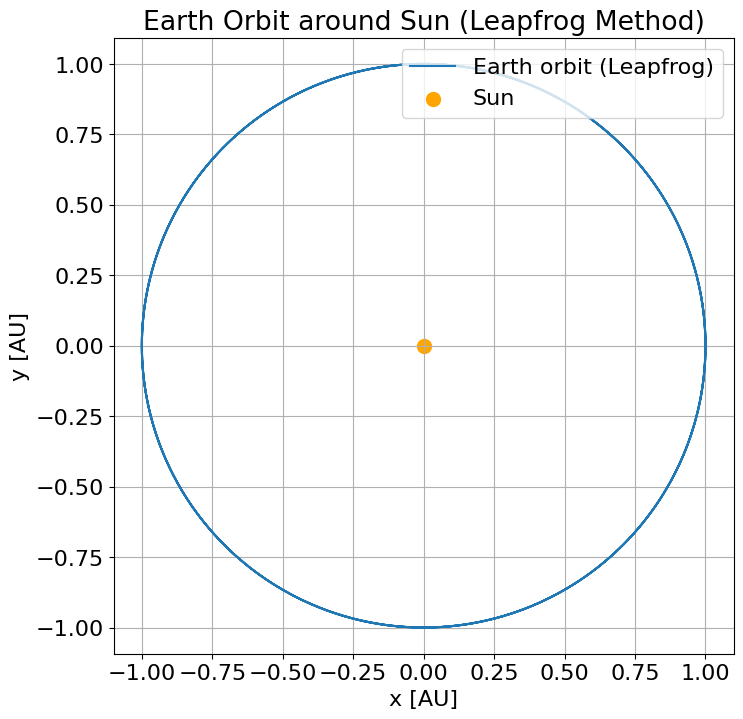

In [171]:
# Plotting the orbit for Leapfrog method
plt.plot(x2, y2, label='Earth orbit (Leapfrog)')
plt.scatter(0, 0, color='orange', s=100, label='Sun')  # Sun at origin
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Earth Orbit around Sun (Leapfrog Method)')
plt.axis('equal')  # equal scaling for x and y
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

In [158]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Earth Orbiting the Sun (Euler Method)')

# Sun and Earth
sun = ax.scatter(0, 0, color='orange', s=200, label='Sun', zorder=5)
orbit_line, = ax.plot([], [], 'b-', alpha=0.4, lw=1)
earth_dot, = ax.plot([], [], 'bo', markersize=10, label='Earth', zorder=10)

ax.legend(loc='upper right')

def init():
    orbit_line.set_data([], [])
    earth_dot.set_data([], [])
    return orbit_line, earth_dot

# Slow down by using fewer points per frame
points_per_frame = 15  # smaller = slower orbit

def update(i):
    idx = i * points_per_frame
    if idx >= len(x1): idx = len(x1) - 1
    
    orbit_line.set_data(x1[:idx], y1[:idx])
    earth_dot.set_data([x1[idx]], [y1[idx]])
    return orbit_line, earth_dot

# Increase interval to 50ms for smoother slower motion
ani = FuncAnimation(fig, update, frames=len(x1)//points_per_frame, 
                    init_func=init, blit=False, interval=50, repeat=False)

plt.close()
display(HTML(ani.to_html5_video()))

In [159]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Earth Orbiting the Sun: Euler vs Leapfrog')

# Sun
sun = ax.scatter(0, 0, color='orange', s=200, label='Sun', zorder=5)

# Orbit lines
orbit_line_euler, = ax.plot([], [], 'b-', lw=1)
orbit_line_leap, = ax.plot([], [], 'r-', lw=1)

# Moving dots
earth_dot_euler, = ax.plot([], [], 'bo', markersize=8, label='Earth (Euler)', zorder=10)
earth_dot_leap, = ax.plot([], [], 'ro', markersize=8, label='Earth (Leapfrog)', zorder=10)

ax.legend(loc='upper right')

def init():
    orbit_line_euler.set_data([], [])
    orbit_line_leap.set_data([], [])
    earth_dot_euler.set_data([], [])
    earth_dot_leap.set_data([], [])
    return orbit_line_euler, orbit_line_leap, earth_dot_euler, earth_dot_leap

points_per_frame = 15  # slower animation

def update(i):
    idx = i * points_per_frame
    if idx >= len(x1): idx = len(x1) - 1  # handle last frame
    
    # Euler orbit
    orbit_line_euler.set_data(x1[:idx], y1[:idx])
    earth_dot_euler.set_data([x1[idx]], [y1[idx]])
    
    # Leapfrog orbit
    orbit_line_leap.set_data(x2[:idx], y2[:idx])
    earth_dot_leap.set_data([x2[idx]], [y2[idx]])
    
    return orbit_line_euler, orbit_line_leap, earth_dot_euler, earth_dot_leap

ani = FuncAnimation(fig, update, frames=len(x1)//points_per_frame, 
                    init_func=init, blit=False, interval=50, repeat=False)

plt.close()
display(HTML(ani.to_html5_video()))

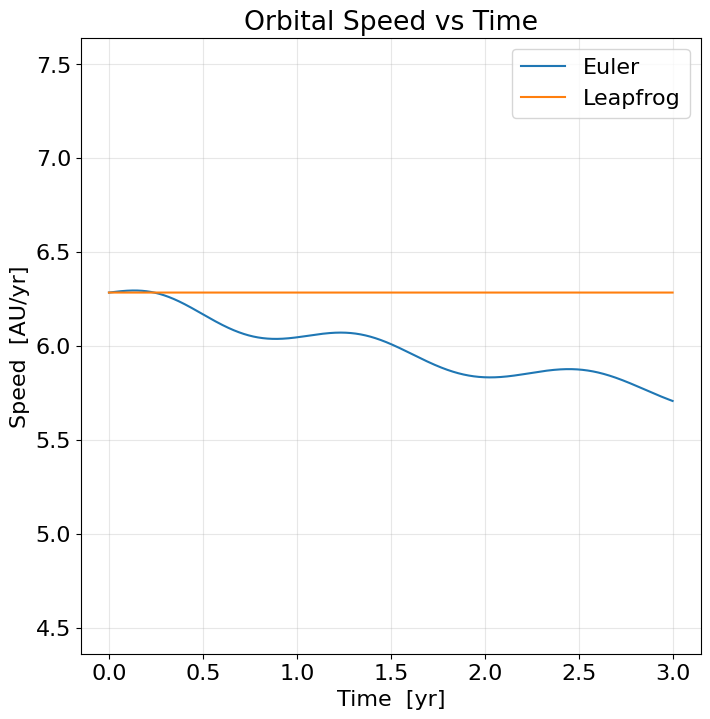

In [160]:
# Plotting speed as a function of time 
speed1 = np.sqrt(vx1**2 + vy1**2)
speed2 = np.sqrt(vx2**2 + vy2**2)

t = np.linspace(0,T,N+1) 
plt.plot( t,speed1, label='Euler')
plt.plot(t,speed2, label= "Leapfrog")
plt.xlabel("Time  [yr]")
plt.ylabel("Speed  [AU/yr]")
plt.title('Orbital Speed vs Time')
plt.axis('equal')  # equal scaling for x and y
plt.legend(loc = "upper right")
plt.grid(True, alpha=0.3)
plt.show()

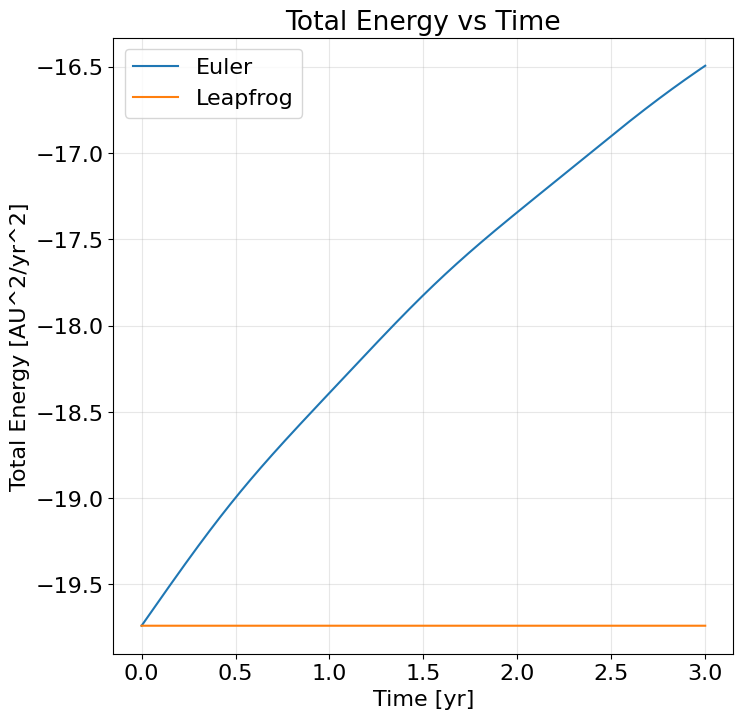

In [162]:
#Total Energy
r1 = np.sqrt(x1**2 + y1**2)
r2 = np.sqrt(x2**2 + y2**2)
Energy1 = 0.5 * speed1**2 - (GM/r1)
Energy2 = 0.5 * speed2**2 - (GM/r2)

# Plot
plt.plot(t, Energy1, label='Euler')
plt.plot(t, Energy2, label='Leapfrog')
plt.xlabel("Time [yr]")
plt.ylabel("Total Energy [AU^2/yr^2]")
plt.title("Total Energy vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [179]:
# New Initial conditions – circular orbit at r0 = 1 AU
vy0 = v_circ*0.8

#  Simulation parameters

T_new = 5.0             # 5 orbital periods
dt      = 1e-3            # time step [yr](This is the step size h)
N_new = int(T / dt)
print(N)

x1,y1,vx1,vy1 = euler_method(x0,y0,vx0,vy0,dt, N_new)
x2,y2,vx2,vy2 = Leapfrog_method(x0,y0,vx0,vy0,dt, N_new)

5000


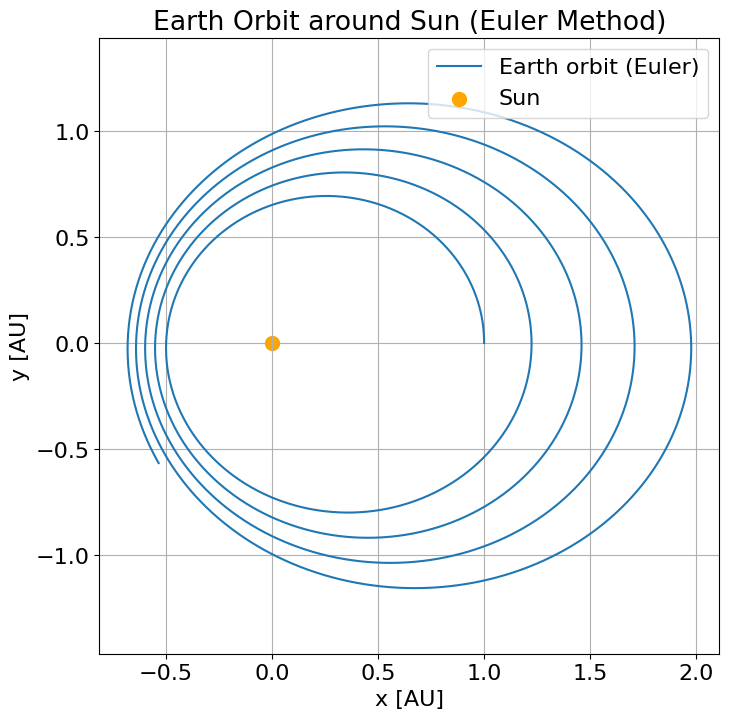

In [180]:
# Plotting the orbit for Euler method
plt.plot(x1, y1, label='Earth orbit (Euler)')
plt.scatter(0, 0, color='orange', s=100, label='Sun')  # Sun at origin
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Earth Orbit around Sun (Euler Method)')
plt.axis('equal')  # equal scaling for x and y
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

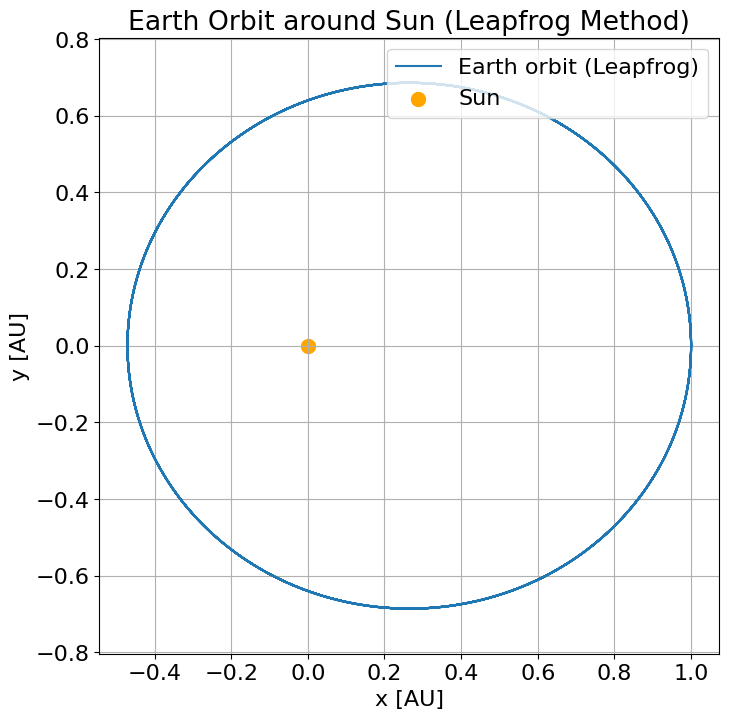

In [181]:
# Plotting the orbit for Leapfrog method
plt.plot(x2, y2, label='Earth orbit (Leapfrog)')
plt.scatter(0, 0, color='orange', s=100, label='Sun')  # Sun at origin
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Earth Orbit around Sun (Leapfrog Method)')
plt.axis('equal')  # equal scaling for x and y
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

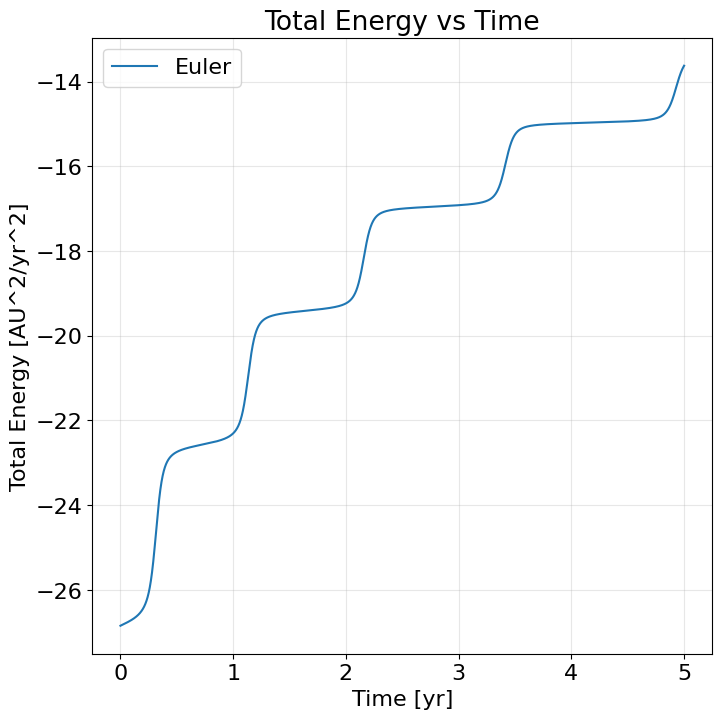

In [183]:
#Total Energy
t=np.linspace(0,T_new,N_new+1)
speed1=np.sqrt(vx1**2 + vy1**2)
speed2=np.sqrt(vx2**2 + vy2**2)
r1 = np.sqrt(x1**2 + y1**2)
r2 = np.sqrt(x2**2 + y2**2)
Energy1 = 0.5 * speed1**2 - (GM/r1)
Energy2 = 0.5 * speed2**2 - (GM/r2)

# Plot
plt.plot(t, Energy1, label='Euler')
plt.xlabel("Time [yr]")
plt.ylabel("Total Energy [AU^2/yr^2]")
plt.title("Total Energy vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

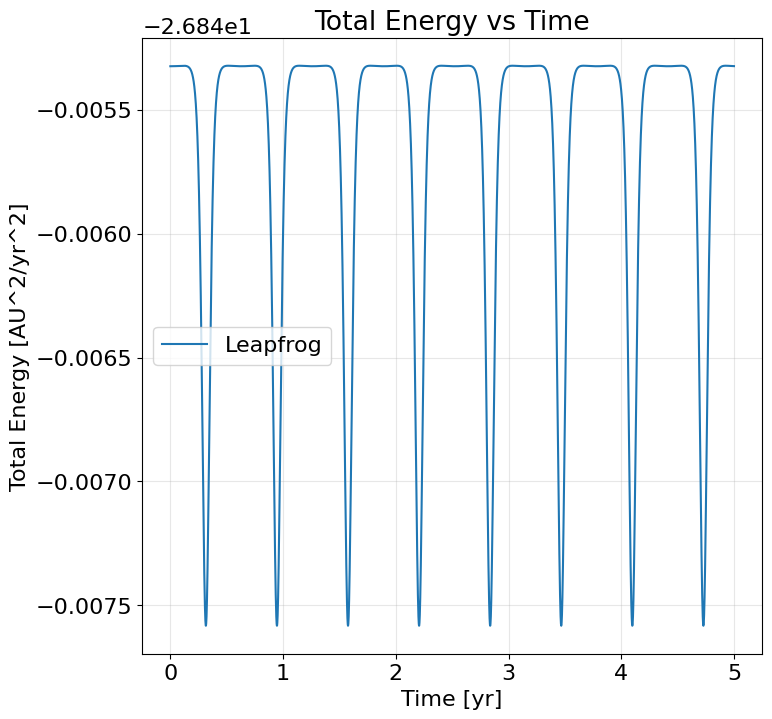

In [184]:
plt.plot(t, Energy2, label='Leapfrog')
plt.xlabel("Time [yr]")
plt.ylabel("Total Energy [AU^2/yr^2]")
plt.title("Total Energy vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()